In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import KBinsDiscretizer, StandardScaler

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [37]:
df = pd.read_csv('populationgroup-wise-deposits.csv')

In [38]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14037 entries, 0 to 14036
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                14037 non-null  int64 
 1   year              14037 non-null  int64 
 2   state_name        14037 non-null  object
 3   state_code        14037 non-null  int64 
 4   district_name     14037 non-null  object
 5   district_code     14037 non-null  int64 
 6   region            14037 non-null  object
 7   population_group  14037 non-null  object
 8   no_of_offices     14037 non-null  int64 
 9   no_of_accounts    14037 non-null  int64 
 10  deposit_amount    14037 non-null  int64 
dtypes: int64(7), object(4)
memory usage: 1.2+ MB
None


In [39]:
df = df.drop_duplicates()

In [40]:
df = df.fillna(df.median(numeric_only=True))   # numeric columns
df = df.fillna(method="ffill").fillna(method="bfill")  # categorical columns

C:\Users\hp\AppData\Local\Temp\ipykernel_10392\1263205742.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill").fillna(method="bfill")  # categorical columns


In [41]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14037 entries, 0 to 14036
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                14037 non-null  int64 
 1   year              14037 non-null  int64 
 2   state_name        14037 non-null  object
 3   state_code        14037 non-null  int64 
 4   district_name     14037 non-null  object
 5   district_code     14037 non-null  int64 
 6   region            14037 non-null  object
 7   population_group  14037 non-null  object
 8   no_of_offices     14037 non-null  int64 
 9   no_of_accounts    14037 non-null  int64 
 10  deposit_amount    14037 non-null  int64 
dtypes: int64(7), object(4)
memory usage: 1.2+ MB
None


In [42]:
kbd = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
df['Deposit_Category'] = kbd.fit_transform(df[['deposit_amount']]).astype(int)


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


In [43]:
X = df[['no_of_offices', 'no_of_accounts']]
y = df['deposit_amount']

In [44]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [45]:
# Scale features for SVM and KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

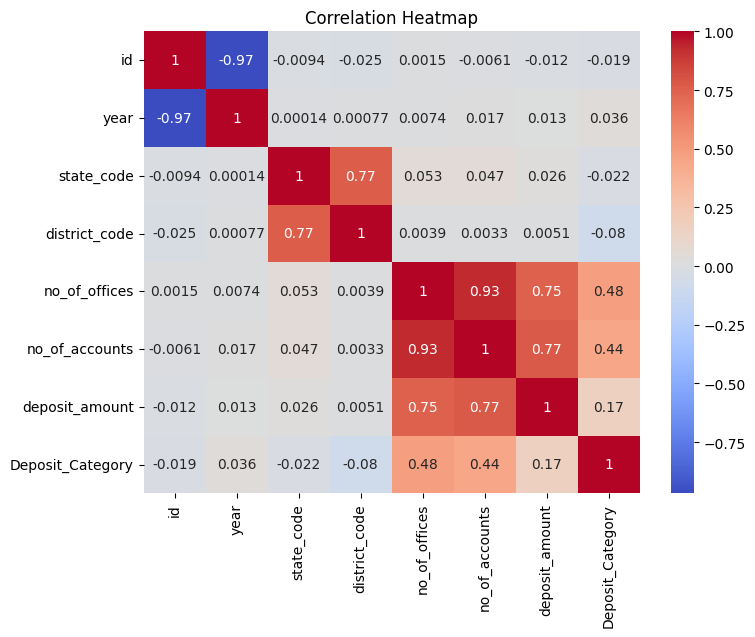

In [46]:
# CORRELATION HEATMAP
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [47]:
os.makedirs("regression_graphs", exist_ok=True)

In [48]:
comparison_results = []

In [54]:
def run_classifier(name, model, scaled=False):
    print(f"\n==================== {name} ====================")
    
    X_tr = X_train_scaled if scaled else X_train
    X_te = X_test_scaled if scaled else X_test
    
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted')
    rec = recall_score(y_test, preds, average='weighted')
    f1 = f1_score(y_test, preds, average='weighted')
    
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    
    cm = confusion_matrix(y_test, preds)
    print("\nConfusion Matrix:")
    print(cm)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{name} - Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"classification_graphs/{name.replace(' ','_')}_confusion_matrix.png")
    plt.show()
    
    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    }

In [55]:

comparison_results.append(run_classifier("Logistic Regression", LogisticRegression(max_iter=1000)))


==================== Logistic Regression ====================


KeyboardInterrupt: 

In [56]:
comparison_results.append(run_classifier("Decision Tree", DecisionTreeClassifier(random_state=42)))

NameError: name 'DecisionTreeClassifier' is not defined


🔹 MODEL : Random Forest
R² Score       : 0.9405
MAE            : 1556.6275
MSE            : 86063176.0048
CrossVal (R²)  : 0.8727


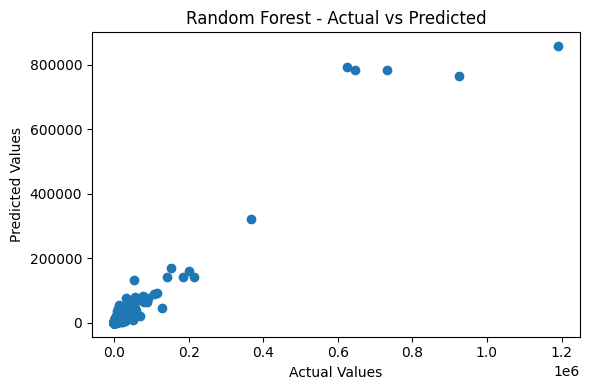

In [ ]:
run_model("Random Forest", RandomForestRegressor())

In [52]:
run_model("SVR", SVR())


==================== SVR ====================


ValueError: Classification metrics can't handle a mix of multiclass and continuous targets

In [53]:
run_model("KNN Regressor", KNeighborsRegressor())


==================== KNN Regressor ====================


ValueError: Classification metrics can't handle a mix of multiclass and continuous targets

In [ ]:
results_df = pd.DataFrame(comparison_results)
print("\n\n===== FINAL MODEL COMPARISON =====\n")
print(results_df)



===== FINAL MODEL COMPARISON =====

               Model  R² Score          MAE           MSE
0  Linear Regression  0.677722  8175.855713  4.662060e+08
1      Decision Tree  0.935516  1799.448302  9.328264e+07
2      Random Forest  0.940506  1556.627535  8.606318e+07
3                SVR -0.004898  3882.152220  1.453680e+09
4      KNN Regressor  0.873281  1916.284615  1.833110e+08


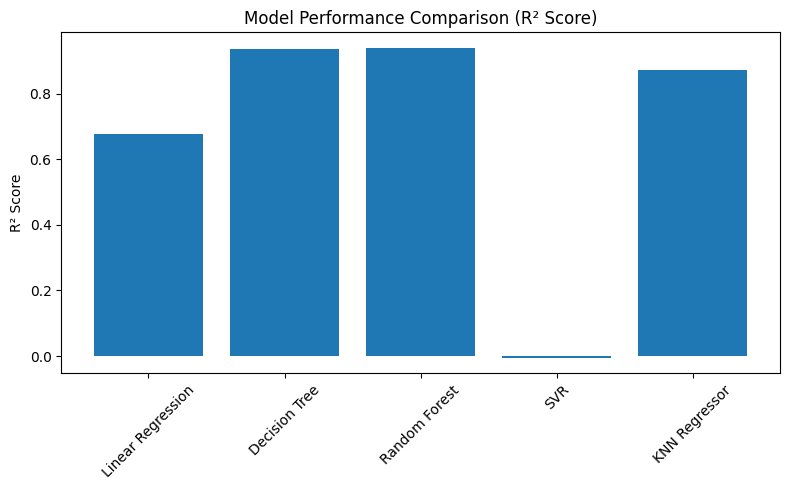

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["R² Score"])
plt.ylabel("R² Score")
plt.title("Model Performance Comparison (R² Score)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("regression_graphs/final_comparison_accuracy.png")
plt.show()